# Extracció i anàlisi de característiques de fluïdesa

**Objectiu**: extreure i analitzar els indicadors de fluïdesa dels àudios processats per identificar diferències entre alumnes amb i sense dislèxia.

Les característiques de fluïdesa temporal (temps d'articulació, pauses, ràtio de fonació) es comparen estadísticament entre els dos grups.

**Entrada**: fitxers `.wav` de `processed_data/`  
**Sortida**: `datasets/fluency_indicators.csv` amb totes les característiques

## 1. Imports i configuració

Importem les llibreries principals:
- `librosa`: anàlisi d'àudio i detecció de segments de parla (silencis vs. parla)
- `scipy` / `statsmodels`: tests estadístics i correcció per comparacions múltiples
- `matplotlib` / `seaborn`: visualització de distribucions i boxplots

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

warnings.filterwarnings('ignore')

AUDIO_ROOT = './processed_data'
OUTPUT_CSV = './datasets/fluency_indicators.csv'

# Recollir tots els .wav
all_wavs = []
for root, _, files in os.walk(AUDIO_ROOT):
    for f in files:
        if f.lower().endswith('.wav'):
            all_wavs.append(os.path.join(root, f))

print(f'Fitxers .wav trobats: {len(all_wavs)}')

Fitxers .wav trobats: 141


## 2. Indicadors de fluïdesa temporal

Calculem els intervals de parla amb `librosa.effects.split` (llindar de silenci -30 dB) per obtenir:

| Variable | Descripció |
|---|---|
| `t_total` | Temps total de lectura (s) |
| `t_art` | Temps efectiu de parla, sense silencis (s) |
| `r_art` | Ràtio de fonació: `t_art / t_total` |
| `n_pauses` | Nombre de pauses detectades |
| `m_pauses` | Durada mitjana de les pauses (s) |
| `t_pauses` | Durada total de les pauses (s) |

In [2]:
def extract_fluency(file_path):
    '''Calcula indicadors de fluïdesa temporal d\'un fitxer .wav.'''
    y, sr = librosa.load(file_path, sr=None)
    t_total = librosa.get_duration(y=y, sr=sr)
    intervals = librosa.effects.split(y, top_db=30)

    speech_durations = [(end - start) / sr for start, end in intervals]
    t_art = sum(speech_durations)
    r_art = t_art / t_total if t_total > 0 else 0.0

    pauses = []
    last_end = 0
    for start, end in intervals:
        if start > last_end:
            pauses.append((start - last_end) / sr)
        last_end = end
    

    return {
        't_total': t_total,
        't_art': t_art,
        'r_art': r_art,
        'n_pauses': len(pauses),
        'm_pauses': float(np.mean(pauses)) if pauses else 0.0,
        't_pauses': sum(pauses),
    }

fluency_records = []
for i, wav in enumerate(all_wavs, start=1):
    if i % 30 == 0 or i == len(all_wavs):
        print(f'Fluïdesa: {i}/{len(all_wavs)}')
    feats = extract_fluency(wav)
    feats['file_name'] = os.path.basename(wav)
    fluency_records.append(feats)

df = pd.DataFrame(fluency_records)
print(f'\nFluïdesa extreta: {len(df)} files')
df.head()

Fluïdesa: 30/141
Fluïdesa: 60/141
Fluïdesa: 90/141
Fluïdesa: 120/141
Fluïdesa: 141/141

Fluïdesa extreta: 141 files


,t_total,t_art,r_art,n_pauses,m_pauses,t_pauses,file_name
0,58.299342,35.561361,0.609979,83,0.268568,22.291156,Aiden8 - Los okapis (Castellano) - LlM_ (Caste...
1,48.124875,32.925896,0.684176,71,0.205219,14.570522,Biel8 - Los okapis (Castellano) - LlM_ (Català...
2,98.049342,56.761179,0.578904,118,0.342396,40.402721,Cala9 - Los okapis (Castellano) - LlM_ (Català...
3,54.722132,39.032744,0.713290,71,0.220917,15.685079,Chloe8 - Los okapis (Castellano) - LlM_ (Caste...
4,71.080952,41.110930,0.578368,100,0.298957,29.895692,D_Alex9 - Los okapis (Castellano) - LlM_ (Cata...


## 3. Anàlisi estadística comparativa (Dislèxia vs Control)

Per a cada variable:
1. **Visualització** amb violin plots + scatter de punts individuals
2. **Test de Welch** (t-test amb variàncies no iguals) per contrast inferencial
3. **Correcció FDR-BH** per comparacions múltiples
4. **Hedges g** com a mida d'efecte robusta

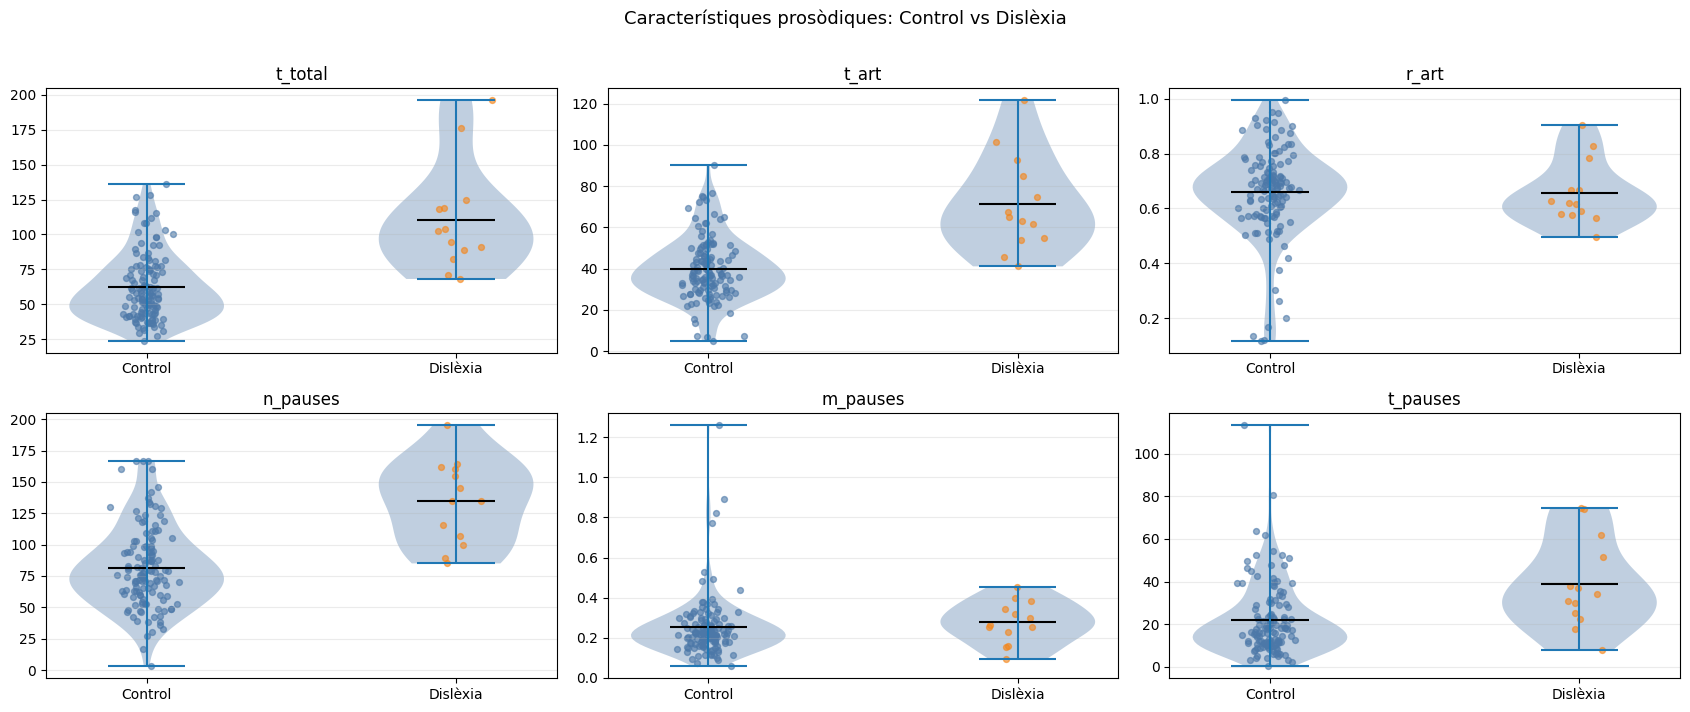

In [3]:
feature_cols = ['t_total', 't_art', 'r_art', 'n_pauses', 'm_pauses', 't_pauses']
df['dyslexia'] = df['file_name'].str.startswith('D_')
rng = np.random.default_rng(42)
ncols = 3
nrows = int(np.ceil(len(feature_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(17, 3.5 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    ctrl = df.loc[df['dyslexia'] == False, col].dropna().to_numpy()
    dys = df.loc[df['dyslexia'] == True, col].dropna().to_numpy()

    if len(ctrl) > 0 and len(dys) > 0:
        parts = ax.violinplot([ctrl, dys], positions=[1, 2], showmeans=True, showextrema=True)
        for pc in parts['bodies']:
            pc.set_alpha(0.35)
            pc.set_facecolor('#4C78A8')
        parts['cmeans'].set_color('black')
        ax.scatter(rng.normal(1, 0.04, len(ctrl)), ctrl, alpha=0.6, s=18, color='#4C78A8')
        ax.scatter(rng.normal(2, 0.04, len(dys)), dys, alpha=0.6, s=18, color='#F58518')
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['Control', 'Dislèxia'])
        ax.set_title(col)
        ax.grid(axis='y', alpha=0.25)

for ax in axes[len(feature_cols):]:
    fig.delaxes(ax)

plt.suptitle('Característiques prosòdiques: Control vs Dislèxia', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('./imatges/prosody_violin_plots.pdf', bbox_inches='tight')
plt.show()

### Correcció FDR i mida d'efecte

Definim dues funcions auxiliars per a la inferència estadística:
- `fdr_bh`: implementació de la correcció de Benjamini-Hochberg, que controla la taxa de falsos positius quan es fan múltiples comparacions simultànies (evita la inflació del error de tipus I)
- `hedges_g`: mida d'efecte estandarditzada, variant de Cohen's d corregida per a mostres petites, que complementa el p-valor amb informació sobre la magnitud de les diferències

Un cop definides, les apliquem a totes les característiques i mostrem la taula de resultats ordenada per significació estadística.

In [4]:
def fdr_bh(p_values):
    '''Correcció de Benjamini-Hochberg per comparacions múltiples.'''
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    p_sorted = p[order]
    prev, q_sorted = 1.0, np.empty(m)
    for i in range(m - 1, -1, -1):
        prev = min(prev, (m / (i + 1)) * p_sorted[i])
        q_sorted[i] = prev
    q = np.empty(m)
    q[order] = np.minimum(q_sorted, 1.0)
    return q


def hedges_g(x, y):
    '''Mida d\'efecte de Hedges g.'''
    x, y = np.asarray(x)[np.isfinite(np.asarray(x))], np.asarray(y)[np.isfinite(np.asarray(y))]
    if len(x) < 2 or len(y) < 2:
        return np.nan
    n1, n2 = len(x), len(y)
    s_pool = np.sqrt(((n1 - 1) * np.var(x, ddof=1) + (n2 - 1) * np.var(y, ddof=1)) / (n1 + n2 - 2))
    if s_pool == 0:
        return 0.0
    d = (np.mean(x) - np.mean(y)) / s_pool
    return d * (1 - 3 / (4 * (n1 + n2) - 9))


rows = []
for feat in feature_cols:
    ctrl_vals = df.loc[df['dyslexia'] == False, feat].dropna()
    dys_vals = df.loc[df['dyslexia'] == True, feat].dropna()
    if len(ctrl_vals) >= 2 and len(dys_vals) >= 2:
        t_stat, p_val = ttest_ind(dys_vals, ctrl_vals, equal_var=False)
    else:
        t_stat, p_val = np.nan, np.nan
    rows.append({
        'variable': feat,
        'n_control': len(ctrl_vals),
        'n_dislexia': len(dys_vals),
        'mitjana_control': ctrl_vals.mean() if len(ctrl_vals) else np.nan,
        'mitjana_dislexia': dys_vals.mean() if len(dys_vals) else np.nan,
        'diferencia': (dys_vals.mean() - ctrl_vals.mean()) if (len(ctrl_vals) and len(dys_vals)) else np.nan,
        't_stat': t_stat,
        'p_value': p_val,
        'hedges_g': hedges_g(dys_vals, ctrl_vals),
    })

df_stats = pd.DataFrame(rows)
valid = df_stats['p_value'].notna()
q_vals = np.full(len(df_stats), np.nan)
if valid.sum() > 0:
    q_vals[valid] = fdr_bh(df_stats.loc[valid, 'p_value'].values)
df_stats['q_value_fdr'] = q_vals
df_stats['significatiu_fdr'] = df_stats['q_value_fdr'] < 0.05
df_stats = df_stats.sort_values('p_value')

print('=== Resultats estadístics (Welch t-test + FDR-BH) ===')
display(df_stats.set_index('variable').round(4))

sig = df_stats[df_stats['significatiu_fdr']]
print(f'\nVariables significatives (q<0.05): {len(sig)}')
if len(sig) > 0:
    for _, r in sig.iterrows():
        print(f'  {r["variable"]}: g={r["hedges_g"]:.3f}, q={r["q_value_fdr"]:.4f}')

=== Resultats estadístics (Welch t-test + FDR-BH) ===


,n_control,n_dislexia,mitjana_control,mitjana_dislexia,diferencia,t_stat,p_value,hedges_g,q_value_fdr,significatiu_fdr
variable,,,,,,,,,,
n_pauses,128,13,81.7109,134.4615,52.7506,5.4620,0.0001,1.6191,0.0005,True
t_art,128,13,39.7148,71.4301,31.7152,4.8109,0.0003,1.9781,0.0010,True
t_total,128,13,62.0340,110.5533,48.5193,4.5178,0.0006,1.9047,0.0012,True
t_pauses,128,13,21.8830,38.8363,16.9533,2.8349,0.0135,0.9821,0.0203,True
m_pauses,128,13,0.2514,0.2763,0.0249,0.7786,0.4465,0.1656,0.5358,False
r_art,128,13,0.6605,0.6557,-0.0048,-0.1351,0.8941,-0.0297,0.8941,False



Variables significatives (q<0.05): 4
  n_pauses: g=1.619, q=0.0005
  t_art: g=1.978, q=0.0010
  t_total: g=1.905, q=0.0012
  t_pauses: g=0.982, q=0.0203


## 4. Guardar resultats

In [9]:
os.makedirs('./datasets', exist_ok=True)

# Dataset complet amb totes les característiques prosòdiques
cols_out = ['file_name', 'dyslexia'] + feature_cols
df[cols_out].to_csv(OUTPUT_CSV, index=False)
print(f'Guardat: {OUTPUT_CSV} ({len(df)} files, {len(feature_cols)} variables)')

Guardat: ./datasets/fluency_indicators.csv (142 files, 6 variables)
